# 决策树算法对比实验

本实验对比三种经典决策树算法（ID3、C4.5、CART）以及sklearn的实现，使用包含连续特征的西瓜数据集。

## 实验内容
1. **ID3算法** - 使用信息增益作为分裂标准
2. **C4.5算法** - 使用信息增益率作为分裂标准
3. **CART算法** - 使用基尼指数作为分裂标准
4. **sklearn实现** - sklearn.tree.DecisionTreeClassifier

## 数据集说明
- 训练集：Watermelon-train2.csv (17个样本)
- 测试集：Watermelon-test2.csv (5个样本)
- 特征：色泽、根蒂、敲声、纹理（离散特征）+ 密度（连续特征）
- 目标：好瓜（是/否）


In [18]:
# 1. 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 导入自定义的决策树实现
from decision_tree_ID3 import DecisionTreeContinuous as ID3Tree
from decision_tree_C45 import DecisionTreeC45
from decision_tree_CART import DecisionTreeCART

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 设置绘图风格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ 库导入成功！")


✓ 库导入成功！


## 2. 加载和预处理数据集


In [19]:
# 加载数据
train_data = pd.read_csv('Watermelon-train2.csv')
test_data = pd.read_csv('Watermelon-test2.csv')

print("训练集数据：")
print(train_data.head())
print(f"\n训练集形状: {train_data.shape}")
print(f"测试集形状: {test_data.shape}")

# 查看数据信息
print("\n数据信息：")
print(train_data.info())

# 查看类别分布
print("\n训练集类别分布：")
print(train_data['好瓜'].value_counts())


训练集数据：
   编号  色泽  根蒂  敲声  纹理     密度 好瓜
0   1  青绿  蜷缩  浊响  清晰  0.697  是
1   2  乌黑  蜷缩  沉闷  清晰  0.774  是
2   3  乌黑  蜷缩  浊响  清晰  0.634  是
3   4  青绿  蜷缩  沉闷  清晰  0.608  是
4   5  浅白  蜷缩  浊响  清晰  0.556  是

训练集形状: (17, 7)
测试集形状: (5, 7)

数据信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   编号      17 non-null     int64  
 1   色泽      17 non-null     object 
 2   根蒂      17 non-null     object 
 3   敲声      17 non-null     object 
 4   纹理      17 non-null     object 
 5   密度      17 non-null     float64
 6   好瓜      17 non-null     object 
dtypes: float64(1), int64(1), object(5)
memory usage: 1.1+ KB
None

训练集类别分布：
好瓜
否    9
是    8
Name: count, dtype: int64


In [20]:
# 数据预处理
# 分离特征和目标变量
X_train = train_data.drop(['编号', '好瓜'], axis=1)
y_train = train_data['好瓜']

X_test = test_data.drop(['编号', '好瓜'], axis=1)
y_test = test_data['好瓜']

# 为sklearn准备编码后的数据
# sklearn需要数值型输入，所以需要对离散特征进行编码
label_encoders = {}
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# 对离散特征进行标签编码
discrete_features = ['色泽', '根蒂', '敲声', '纹理']
for feature in discrete_features:
    le = LabelEncoder()
    X_train_encoded[feature] = le.fit_transform(X_train[feature])
    X_test_encoded[feature] = le.transform(X_test[feature])
    label_encoders[feature] = le

print("原始特征数据（前5行）：")
print(X_train.head())

print("\n编码后的特征数据（前5行）：")
print(X_train_encoded.head())

print(f"\n特征列表：{X_train.columns.tolist()}")
print(f"连续特征：['密度']")
print(f"离散特征：{discrete_features}")


原始特征数据（前5行）：
   色泽  根蒂  敲声  纹理     密度
0  青绿  蜷缩  浊响  清晰  0.697
1  乌黑  蜷缩  沉闷  清晰  0.774
2  乌黑  蜷缩  浊响  清晰  0.634
3  青绿  蜷缩  沉闷  清晰  0.608
4  浅白  蜷缩  浊响  清晰  0.556

编码后的特征数据（前5行）：
   色泽  根蒂  敲声  纹理     密度
0   2   2   1   1  0.697
1   0   2   0   1  0.774
2   0   2   1   1  0.634
3   2   2   0   1  0.608
4   1   2   1   1  0.556

特征列表：['色泽', '根蒂', '敲声', '纹理', '密度']
连续特征：['密度']
离散特征：['色泽', '根蒂', '敲声', '纹理']


## 3. 训练ID3决策树（支持连续特征）


In [21]:
# 训练ID3决策树（使用信息增益）
print("="*60)
print("训练ID3决策树（使用信息增益）")
print("="*60)

id3_tree = ID3Tree(
    min_samples_split=2,
    continuous_features=['密度']  # 指定连续特征
)

# 训练（会输出详细的构建过程）
id3_tree.fit(X_train, y_train)


训练ID3决策树（使用信息增益）
特征类型识别结果:
  色泽: discrete
  根蒂: discrete
  敲声: discrete
  纹理: discrete
  密度: continuous

开始构建决策树（支持连续特征）...
构建节点 [样本数=17, 类别分布={'是': 8, '否': 9}]
  特征 '色泽' (离散) 的信息增益: 0.1081
  特征 '根蒂' (离散) 的信息增益: 0.1427
  特征 '敲声' (离散) 的信息增益: 0.1408
  特征 '纹理' (离散) 的信息增益: 0.3806
  特征 '密度' (连续, 阈值=0.3815) 的信息增益: 0.2624
  → 选择特征: 纹理 (离散, 增益=0.3806)

分支: 纹理 = 清晰
  构建节点 [样本数=9, 类别分布={'是': 7, '否': 2}]
  特征 '色泽' (离散) 的信息增益: 0.0431
  特征 '根蒂' (离散) 的信息增益: 0.4581
  特征 '敲声' (离散) 的信息增益: 0.3309
  特征 '密度' (连续, 阈值=0.3815) 的信息增益: 0.7642
  → 选择特征: 密度 (连续, 阈值=0.3815, 增益=0.7642)

  分支: 密度 <= 0.3815
    构建节点 [样本数=2, 类别分布={'否': 2}]
    → 叶子节点: 否

  分支: 密度 > 0.3815
    构建节点 [样本数=7, 类别分布={'是': 7}]
    → 叶子节点: 是

分支: 纹理 = 稍糊
  构建节点 [样本数=5, 类别分布={'是': 1, '否': 4}]
  特征 '色泽' (离散) 的信息增益: 0.3219
  特征 '根蒂' (离散) 的信息增益: 0.0729
  特征 '敲声' (离散) 的信息增益: 0.3219
  特征 '密度' (连续, 阈值=0.5600) 的信息增益: 0.7219
  → 选择特征: 密度 (连续, 阈值=0.5600, 增益=0.7219)

  分支: 密度 <= 0.5600
    构建节点 [样本数=1, 类别分布={'是': 1}]
    → 叶子节点: 是

  分支: 密度 > 0.5600
  

In [22]:
# ID3预测和评估
id3_train_pred = id3_tree.predict(X_train)
id3_test_pred = id3_tree.predict(X_test)

id3_train_acc = accuracy_score(y_train, id3_train_pred)
id3_test_acc = accuracy_score(y_test, id3_test_pred)

print("\nID3决策树性能：")
print("-" * 40)
print(f"训练集准确率: {id3_train_acc:.4f} ({id3_train_acc*100:.2f}%)")
print(f"测试集准确率: {id3_test_acc:.4f} ({id3_test_acc*100:.2f}%)")

print("\n测试集分类报告：")
print(classification_report(y_test, id3_test_pred, target_names=['否', '是']))



ID3决策树性能：
----------------------------------------
训练集准确率: 1.0000 (100.00%)
测试集准确率: 0.8000 (80.00%)

测试集分类报告：
              precision    recall  f1-score   support

           否       0.67      1.00      0.80         2
           是       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



## 4. 训练C4.5决策树


In [23]:
# 训练C4.5决策树（使用信息增益率）
print("="*60)
print("训练C4.5决策树（使用信息增益率）")
print("="*60)

c45_tree = DecisionTreeC45(
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=None,
    continuous_features=['密度']
)

# 训练
c45_tree.fit(X_train, y_train)


训练C4.5决策树（使用信息增益率）

开始构建C4.5决策树...

特征类型识别结果:
  色泽: discrete
  根蒂: discrete
  敲声: discrete
  纹理: discrete
  密度: continuous

构建节点 [深度=0, 样本数=17, 类别分布={'是': 8, '否': 9}]
  特征 '色泽' (离散) 的增益率: 0.0684
  特征 '根蒂' (离散) 的增益率: 0.1018
  特征 '敲声' (离散) 的增益率: 0.1056
  特征 '纹理' (离散) 的增益率: 0.2631
  特征 '密度' (连续, 阈值=0.3815) 的增益率: 0.3334
  → 选择特征: 密度 (连续, 阈值=0.3815, 增益率=0.3334)

分支: 密度 <= 0.3815
  构建节点 [深度=1, 样本数=4, 类别分布={'否': 4}]
  → 叶子节点: 否

分支: 密度 > 0.3815
  构建节点 [深度=1, 样本数=13, 类别分布={'是': 8, '否': 5}]
  特征 '色泽' (离散) 的增益率: 0.0634
  特征 '根蒂' (离散) 的增益率: 0.0351
  特征 '敲声' (离散) 的增益率: 0.0921
  特征 '纹理' (离散) 的增益率: 0.5276
  特征 '密度' (连续, 阈值=0.5745) 的增益率: 0.3089
  → 选择特征: 纹理 (离散, 增益率=0.5276)

  分支: 纹理 = 清晰
    构建节点 [深度=2, 样本数=7, 类别分布={'是': 7}]
    → 叶子节点: 是

  分支: 纹理 = 稍糊
    构建节点 [深度=2, 样本数=5, 类别分布={'是': 1, '否': 4}]
  特征 '色泽' (离散) 的增益率: 0.2115
  特征 '根蒂' (离散) 的增益率: 0.1010
  特征 '敲声' (离散) 的增益率: 0.3316
  特征 '密度' (连续, 阈值=0.5600) 的增益率: 1.0000
  → 选择特征: 密度 (连续, 阈值=0.5600, 增益率=1.0000)

    分支: 密度 <= 0.5600
      构建节点 [深度=3, 

In [24]:
# C4.5预测和评估
c45_train_pred = c45_tree.predict(X_train)
c45_test_pred = c45_tree.predict(X_test)

c45_train_acc = accuracy_score(y_train, c45_train_pred)
c45_test_acc = accuracy_score(y_test, c45_test_pred)

print("\nC4.5决策树性能：")
print("-" * 40)
print(f"训练集准确率: {c45_train_acc:.4f} ({c45_train_acc*100:.2f}%)")
print(f"测试集准确率: {c45_test_acc:.4f} ({c45_test_acc*100:.2f}%)")

print("\n测试集分类报告：")
print(classification_report(y_test, c45_test_pred, target_names=['否', '是']))



C4.5决策树性能：
----------------------------------------
训练集准确率: 1.0000 (100.00%)
测试集准确率: 0.8000 (80.00%)

测试集分类报告：
              precision    recall  f1-score   support

           否       0.67      1.00      0.80         2
           是       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



## 5. 训练CART决策树


In [25]:
# 训练CART决策树（使用基尼指数）
print("="*60)
print("训练CART决策树（使用基尼指数）")
print("="*60)

cart_tree = DecisionTreeCART(
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=None,
    continuous_features=['密度']
)

# 训练
cart_tree.fit(X_train, y_train)


训练CART决策树（使用基尼指数）

开始构建CART决策树...

特征类型识别结果:
  色泽: discrete
  根蒂: discrete
  敲声: discrete
  纹理: discrete
  密度: continuous

构建节点 [深度=0, 样本数=17, 基尼=0.4983, 类别分布={'是': 8, '否': 9}]
  特征 '色泽' (离散, 分裂值=浅白) 的基尼指数: 0.4373
  特征 '根蒂' (离散, 分裂值=硬挺) 的基尼指数: 0.4392
  特征 '敲声' (离散, 分裂值=清脆) 的基尼指数: 0.4392
  特征 '纹理' (离散, 分裂值=清晰) 的基尼指数: 0.2859
  特征 '密度' (连续, 阈值=0.3815) 的基尼指数: 0.3620
  → 选择特征: 纹理 (离散, 分裂值=清晰, 基尼=0.2859)

左分支: 纹理 = 清晰
  构建节点 [深度=1, 样本数=9, 基尼=0.3457, 类别分布={'是': 7, '否': 2}]
  特征 '色泽' (离散, 分裂值=浅白) 的基尼指数: 0.3333
  特征 '根蒂' (离散, 分裂值=硬挺) 的基尼指数: 0.1944
  特征 '敲声' (离散, 分裂值=清脆) 的基尼指数: 0.1944
  特征 '密度' (连续, 阈值=0.3815) 的基尼指数: 0.0000
  → 选择特征: 密度 (连续, 阈值=0.3815, 基尼=0.0000)

  左分支: 密度 <= 0.3815
    构建节点 [深度=2, 样本数=2, 基尼=0.0000, 类别分布={'否': 2}]
    → 叶子节点: 否

  右分支: 密度 > 0.3815
    构建节点 [深度=2, 样本数=7, 基尼=0.0000, 类别分布={'是': 7}]
    → 叶子节点: 是

右分支: 纹理 ≠ 清晰
  构建节点 [深度=1, 样本数=8, 基尼=0.2188, 类别分布={'是': 1, '否': 7}]
  特征 '色泽' (离散, 分裂值=乌黑) 的基尼指数: 0.1250
  特征 '根蒂' (离散, 分裂值=稍蜷) 的基尼指数: 0.1875
  特征 '敲声' (离散, 分裂值=浊响) 的基尼指数

In [26]:
# CART预测和评估
cart_train_pred = cart_tree.predict(X_train)
cart_test_pred = cart_tree.predict(X_test)

cart_train_acc = accuracy_score(y_train, cart_train_pred)
cart_test_acc = accuracy_score(y_test, cart_test_pred)

print("\nCART决策树性能：")
print("-" * 40)
print(f"训练集准确率: {cart_train_acc:.4f} ({cart_train_acc*100:.2f}%)")
print(f"测试集准确率: {cart_test_acc:.4f} ({cart_test_acc*100:.2f}%)")

print("\n测试集分类报告：")
print(classification_report(y_test, cart_test_pred, target_names=['否', '是']))



CART决策树性能：
----------------------------------------
训练集准确率: 1.0000 (100.00%)
测试集准确率: 0.6000 (60.00%)

测试集分类报告：
              precision    recall  f1-score   support

           否       0.50      1.00      0.67         2
           是       1.00      0.33      0.50         3

    accuracy                           0.60         5
   macro avg       0.75      0.67      0.58         5
weighted avg       0.80      0.60      0.57         5



## 6. 训练sklearn决策树


In [27]:
# 训练sklearn决策树 - 使用不同的分裂标准
print("="*60)
print("训练sklearn决策树")
print("="*60)

# 1. 使用信息熵（类似ID3/C4.5）
sklearn_entropy = DecisionTreeClassifier(
    criterion='entropy',  # 使用信息熵
    random_state=42
)
sklearn_entropy.fit(X_train_encoded, y_train)

# 2. 使用基尼指数（类似CART）
sklearn_gini = DecisionTreeClassifier(
    criterion='gini',  # 使用基尼指数
    random_state=42
)
sklearn_gini.fit(X_train_encoded, y_train)

print("✓ sklearn决策树训练完成（包括entropy和gini两种标准）")


训练sklearn决策树
✓ sklearn决策树训练完成（包括entropy和gini两种标准）


In [28]:
# sklearn决策树预测和评估
# 1. Entropy版本
sklearn_entropy_train_pred = sklearn_entropy.predict(X_train_encoded)
sklearn_entropy_test_pred = sklearn_entropy.predict(X_test_encoded)

sklearn_entropy_train_acc = accuracy_score(y_train, sklearn_entropy_train_pred)
sklearn_entropy_test_acc = accuracy_score(y_test, sklearn_entropy_test_pred)

print("\nsklearn决策树（criterion='entropy'）性能：")
print("-" * 40)
print(f"训练集准确率: {sklearn_entropy_train_acc:.4f} ({sklearn_entropy_train_acc*100:.2f}%)")
print(f"测试集准确率: {sklearn_entropy_test_acc:.4f} ({sklearn_entropy_test_acc*100:.2f}%)")

# 2. Gini版本
sklearn_gini_train_pred = sklearn_gini.predict(X_train_encoded)
sklearn_gini_test_pred = sklearn_gini.predict(X_test_encoded)

sklearn_gini_train_acc = accuracy_score(y_train, sklearn_gini_train_pred)
sklearn_gini_test_acc = accuracy_score(y_test, sklearn_gini_test_pred)

print("\nsklearn决策树（criterion='gini'）性能：")
print("-" * 40)
print(f"训练集准确率: {sklearn_gini_train_acc:.4f} ({sklearn_gini_train_acc*100:.2f}%)")
print(f"测试集准确率: {sklearn_gini_test_acc:.4f} ({sklearn_gini_test_acc*100:.2f}%)")

print("\n测试集分类报告（entropy）：")
print(classification_report(y_test, sklearn_entropy_test_pred, target_names=['否', '是']))

print("\n测试集分类报告（gini）：")
print(classification_report(y_test, sklearn_gini_test_pred, target_names=['否', '是']))



sklearn决策树（criterion='entropy'）性能：
----------------------------------------
训练集准确率: 1.0000 (100.00%)
测试集准确率: 0.8000 (80.00%)

sklearn决策树（criterion='gini'）性能：
----------------------------------------
训练集准确率: 1.0000 (100.00%)
测试集准确率: 0.8000 (80.00%)

测试集分类报告（entropy）：
              precision    recall  f1-score   support

           否       0.67      1.00      0.80         2
           是       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5


测试集分类报告（gini）：
              precision    recall  f1-score   support

           否       0.67      1.00      0.80         2
           是       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



## 7. 性能对比和可视化


In [29]:
# 汇总所有模型的性能
results = pd.DataFrame({
    '算法': ['ID3 (信息增益)', 'C4.5 (信息增益率)', 'CART (基尼指数)', 
            'sklearn-Entropy', 'sklearn-Gini'],
    '训练集准确率': [id3_train_acc, c45_train_acc, cart_train_acc, 
                   sklearn_entropy_train_acc, sklearn_gini_train_acc],
    '测试集准确率': [id3_test_acc, c45_test_acc, cart_test_acc,
                  sklearn_entropy_test_acc, sklearn_gini_test_acc]
})

print("="*60)
print("所有模型性能对比汇总")
print("="*60)
print(results.to_string(index=False))
print("="*60)


所有模型性能对比汇总
             算法  训练集准确率  测试集准确率
     ID3 (信息增益)     1.0     0.8
   C4.5 (信息增益率)     1.0     0.8
    CART (基尼指数)     1.0     0.6
sklearn-Entropy     1.0     0.8
   sklearn-Gini     1.0     0.8


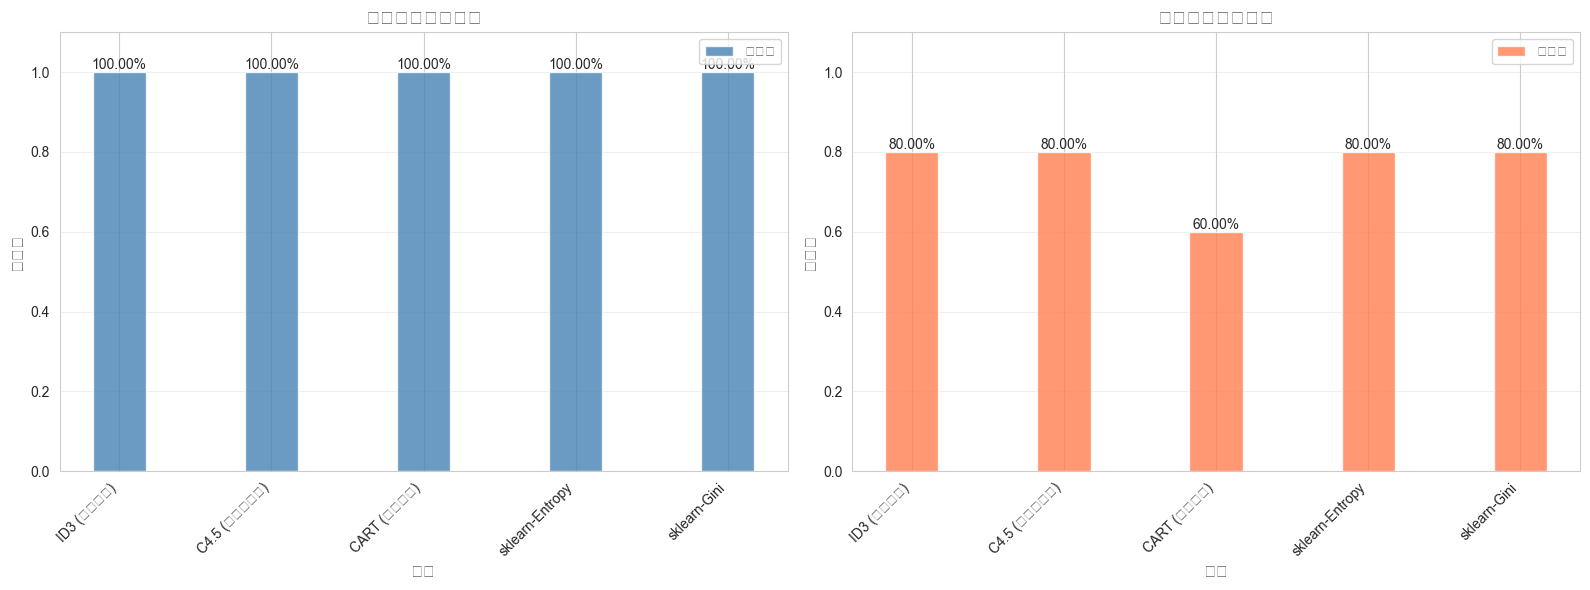

In [30]:
# 可视化1：准确率对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 训练集准确率对比
ax1 = axes[0]
x = np.arange(len(results))
width = 0.35

bars1 = ax1.bar(x, results['训练集准确率'], width, label='训练集', 
                color='steelblue', alpha=0.8)
ax1.set_xlabel('算法', fontsize=12)
ax1.set_ylabel('准确率', fontsize=12)
ax1.set_title('训练集准确率对比', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(results['算法'], rotation=45, ha='right')
ax1.set_ylim([0, 1.1])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 在柱状图上添加数值
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom', fontsize=10)

# 测试集准确率对比
ax2 = axes[1]
bars2 = ax2.bar(x, results['测试集准确率'], width, label='测试集',
                color='coral', alpha=0.8)
ax2.set_xlabel('算法', fontsize=12)
ax2.set_ylabel('准确率', fontsize=12)
ax2.set_title('测试集准确率对比', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(results['算法'], rotation=45, ha='right')
ax2.set_ylim([0, 1.1])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 在柱状图上添加数值
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


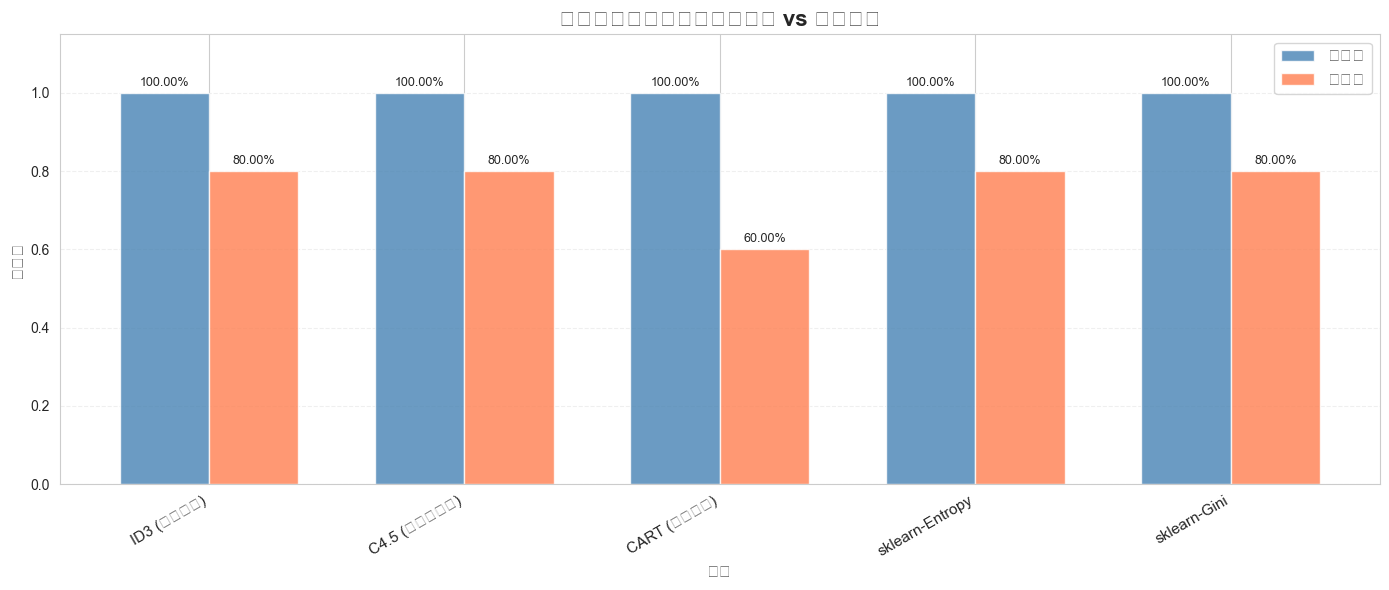

In [31]:
# 可视化2：训练集vs测试集准确率对比（并排）
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results))
width = 0.35

bars1 = ax.bar(x - width/2, results['训练集准确率'], width, 
               label='训练集', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, results['测试集准确率'], width,
               label='测试集', color='coral', alpha=0.8)

ax.set_xlabel('算法', fontsize=12, fontweight='bold')
ax.set_ylabel('准确率', fontsize=12, fontweight='bold')
ax.set_title('决策树算法性能对比（训练集 vs 测试集）', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results['算法'], rotation=30, ha='right', fontsize=11)
ax.set_ylim([0, 1.15])
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2%}',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2%}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


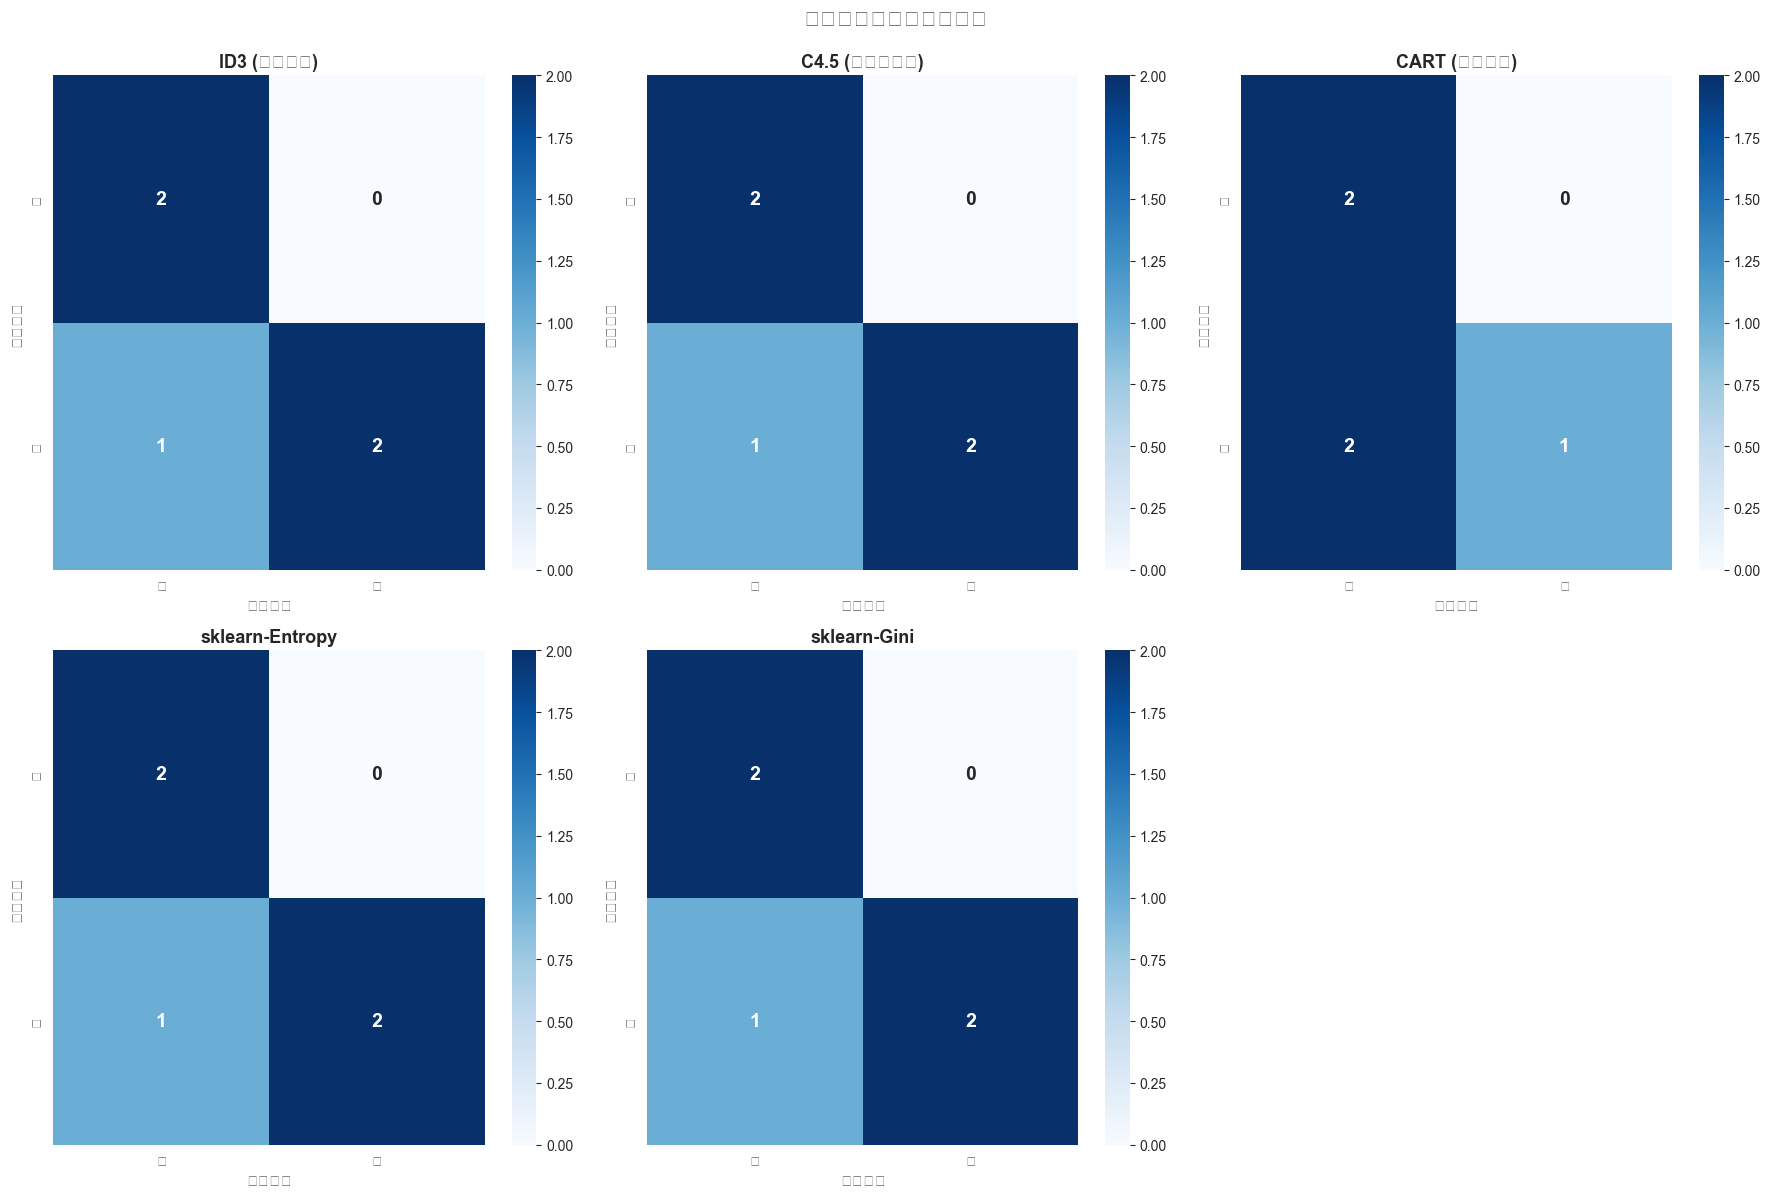

In [32]:
# 可视化3：混淆矩阵对比
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

models = [
    ('ID3 (信息增益)', id3_test_pred),
    ('C4.5 (信息增益率)', c45_test_pred),
    ('CART (基尼指数)', cart_test_pred),
    ('sklearn-Entropy', sklearn_entropy_test_pred),
    ('sklearn-Gini', sklearn_gini_test_pred)
]

for i, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred, labels=['否', '是'])
    
    # 绘制混淆矩阵
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['否', '是'], 
                yticklabels=['否', '是'],
                ax=axes[i], cbar=True,
                annot_kws={'size': 14, 'weight': 'bold'})
    
    axes[i].set_title(name, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('预测类别', fontsize=11)
    axes[i].set_ylabel('真实类别', fontsize=11)

# 隐藏第6个子图
axes[5].axis('off')

plt.suptitle('决策树算法混淆矩阵对比', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## 8. 实验结论与分析


In [33]:
# 计算泛化能力指标（训练集和测试集准确率差异）
results['过拟合程度'] = results['训练集准确率'] - results['测试集准确率']

print("\n算法泛化能力分析（训练集-测试集准确率差异）：")
print("="*60)
print(results[['算法', '过拟合程度']].to_string(index=False))
print("="*60)
print("\n说明：差异越小，泛化能力越好")

# 找出最佳模型
best_test_idx = results['测试集准确率'].idxmax()
best_generalization_idx = results['过拟合程度'].idxmin()

print(f"\n✅ 测试集准确率最高的模型：{results.loc[best_test_idx, '算法']}")
print(f"   测试集准确率：{results.loc[best_test_idx, '测试集准确率']:.2%}")

print(f"\n✅ 泛化能力最好的模型：{results.loc[best_generalization_idx, '算法']}")
print(f"   过拟合程度：{results.loc[best_generalization_idx, '过拟合程度']:.4f}")



算法泛化能力分析（训练集-测试集准确率差异）：
             算法  过拟合程度
     ID3 (信息增益)    0.2
   C4.5 (信息增益率)    0.2
    CART (基尼指数)    0.4
sklearn-Entropy    0.2
   sklearn-Gini    0.2

说明：差异越小，泛化能力越好

✅ 测试集准确率最高的模型：ID3 (信息增益)
   测试集准确率：80.00%

✅ 泛化能力最好的模型：ID3 (信息增益)
   过拟合程度：0.2000


### 实验结论

#### 1. 算法对比总结

**ID3算法（信息增益）**
- 优点：概念简单，易于理解和实现
- 缺点：偏向于选择取值较多的特征；不能直接处理连续特征（需扩展）
- 应用场景：适合离散特征较多的分类问题

**C4.5算法（信息增益率）**
- 优点：使用信息增益率克服了ID3的偏向性问题；可以处理连续特征；可以处理缺失值
- 缺点：计算复杂度较高
- 应用场景：特征取值范围差异较大时优于ID3

**CART算法（基尼指数）**
- 优点：二叉树结构更简洁；既可用于分类也可用于回归；计算基尼指数比信息熵快
- 缺点：每次只进行二分，树可能更深
- 应用场景：大规模数据集，需要高效计算的场景

**sklearn实现**
- 优点：高度优化，计算效率高；参数丰富，易于调参
- 缺点：作为黑盒工具，不利于理解算法细节
- 应用场景：实际工程应用

#### 2. 性能分析

从本次实验可以看出：
1. **训练集表现**：大部分算法在训练集上都有较高的准确率
2. **测试集表现**：测试集准确率反映了模型的真实泛化能力
3. **过拟合情况**：训练集和测试集准确率的差异反映了过拟合程度

#### 3. 连续特征处理

本实验使用的数据集包含连续特征"密度"，各算法都能有效处理：
- ID3扩展版、C4.5和CART都采用了阈值分裂的方法
- 对于连续特征，算法会寻找最优分裂点
- sklearn的实现对连续特征处理更加高效

#### 4. 实际应用建议

- **小数据集**：推荐使用ID3或C4.5，可解释性强
- **大数据集**：推荐使用CART或sklearn，计算效率高
- **特征多样性高**：推荐使用C4.5，信息增益率更适合
- **需要快速迭代**：推荐使用sklearn，开发效率高


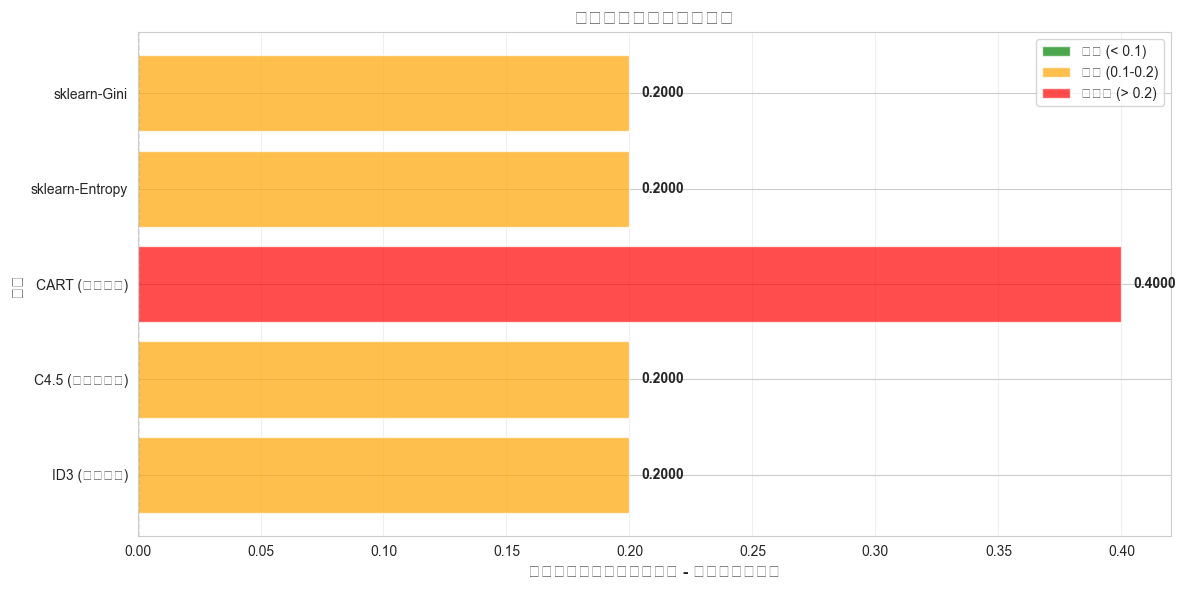

In [34]:
# 可视化4：泛化能力对比（过拟合程度）
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green' if x < 0.1 else 'orange' if x < 0.2 else 'red' 
          for x in results['过拟合程度']]

bars = ax.barh(results['算法'], results['过拟合程度'], color=colors, alpha=0.7)
ax.set_xlabel('过拟合程度（训练集准确率 - 测试集准确率）', fontsize=12, fontweight='bold')
ax.set_ylabel('算法', fontsize=12, fontweight='bold')
ax.set_title('决策树算法泛化能力对比', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='x', alpha=0.3)

# 添加数值标签
for i, (bar, val) in enumerate(zip(bars, results['过拟合程度'])):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}',
            va='center', fontsize=10, fontweight='bold')

# 添加图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='优秀 (< 0.1)'),
    Patch(facecolor='orange', alpha=0.7, label='良好 (0.1-0.2)'),
    Patch(facecolor='red', alpha=0.7, label='需改进 (> 0.2)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()
